# Cpu Scheduling Simulator

This notebook includes:
- preprocessing
- Bayes (Gaussian) classifier from scratch
- Kernel Discriminant Analysis (KDA / Kernel LDA) from scratch (RBF + Polynomial)
- scikit-learn classifiers on full features and PCA features
- comparison + discussion

> **Note on kernel methods (SVM kernels, Kernel PCA, KDA):** these methods scale as **O(n²)** memory/time in the number of training samples. To keep computation feasible, this notebook uses a **stratified subsample** for kernel-based models.

## Part 0: Imports & Helper Utilities

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)

from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA, KernelPCA

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def evaluate_classifier(name, y_true, y_pred, labels=None, show_cm=False):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 (macro):", f1_score(y_true, y_pred, average="macro"))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if show_cm:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix — {name}")
        plt.show()
    return {
        "Classifier": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1_macro": f1_score(y_true, y_pred, average="macro"),
        "CM": cm
    }

def stratified_subsample(X, y, n_samples, random_state=RANDOM_STATE):
    df_tmp = pd.DataFrame(np.asarray(X))
    df_tmp["y"] = np.asarray(y)
    per_class = max(1, n_samples // df_tmp["y"].nunique())
    parts = []
    for c, g in df_tmp.groupby("y"):
        parts.append(g.sample(n=min(per_class, len(g)), random_state=random_state))
    out = pd.concat(parts).sample(frac=1, random_state=random_state)
    y_out = out["y"].to_numpy()
    X_out = out.drop(columns=["y"]).to_numpy()
    return X_out, y_out


# Speed settings (keep notebook runnable)
FAST_TRAIN_SUB = 15000
FAST_TEST_SUB  = 5000


## Part 1: Data Preprocessing
### 1) Load the Dataset

In [ ]:

# Place Activity_data.csv in the same folder as this notebook
import os
csv_path = "Activity_data.csv"
if not os.path.exists(csv_path):
    csv_path = "/mnt/data/Activity_data.csv"
df = pd.read_csv(csv_path)

print("First 10 rows:")
display(df.head(10))

print("\nDataset shape (rows, cols):", df.shape)

print("\nColumn names:")
display(df.columns)

print("\nMissing values per column:")
display(df.isna().sum())

# Handling missing values:
# This dataset shows 0 missing values. If missing values existed:
# - drop rows if missingness is tiny and random, or
# - impute (mean/median) if missingness is larger.


First 10 rows:


,Time,frontal_axis_Acceleration,vertical_axis+_Acceleration,lateral_axis_Acceleration,Antenna_ID_Sensor,RSSI,Phase,Frequency,Activity
0,0.00,-0.232160,0.215880,-1.18820,2,-48.5,2.74430,920.75,3
1,0.25,-0.056282,0.043636,-1.14260,2,-50.0,2.36540,921.75,3
2,0.50,0.143050,0.296270,-1.33640,3,-59.5,0.20709,922.25,3
3,0.75,0.318930,0.284780,-0.92593,2,-51.0,0.41571,923.25,3
4,1.05,0.412730,0.135500,-1.02860,2,-44.5,4.45470,920.25,3
5,1.25,0.318930,0.238850,-0.97154,2,-52.0,1.54010,925.75,3
6,1.50,0.143050,0.296270,-1.01720,2,-52.0,1.87760,924.25,3
7,1.75,0.143050,0.296270,-1.01720,2,-51.5,1.77940,924.75,3
8,2.00,0.166500,0.135500,-0.83470,3,-63.5,2.31940,922.75,3
9,2.75,0.166500,0.135500,-0.83470,2,-60.5,4.84740,921.75,3



Dataset shape (rows, cols): (75128, 9)

Column names:


Index(['Time', 'frontal_axis_Acceleration', 'vertical_axis+_Acceleration',
       'lateral_axis_Acceleration', 'Antenna_ID_Sensor', 'RSSI', ' Phase',
       'Frequency', 'Activity'],
      dtype='object')


Missing values per column:


,0
Time,0
frontal_axis_Acceleration,0
vertical_axis+_Acceleration,0
lateral_axis_Acceleration,0
Antenna_ID_Sensor,0
RSSI,0
Phase,0
Frequency,0
Activity,0


### 2) Separate Features (X) and Labels (y)

In [ ]:

label_col = "Activity"
X = df.drop(columns=[label_col])
y = df[label_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique classes:", sorted(y.unique()))


X shape: (75128, 8)
y shape: (75128,)
Unique classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### 3) Train–Test Split (80/20)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
labels_sorted = sorted(y.unique())


Train shape: (60102, 8)  Test shape: (15026, 8)


### 4) Feature Scaling (StandardScaler)

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled train shape: (60102, 8)
Scaled test shape: (15026, 8)


## Part 2: Classification on the Entire Dataset (No PCA)
### A) Bayesian Classifier (From Scratch) — Gaussian likelihood

In [ ]:

class GaussianBayesScratch:
    # Multiclass Gaussian Bayes classifier (from scratch)
    # - Estimates class priors
    # - Estimates class mean vector and full covariance matrix for each class
    # - Uses log-posterior = log prior + log Gaussian likelihood
    def __init__(self, reg=1e-3):
        self.reg = reg
        self.classes_ = None
        self.priors_ = {}
        self.means_ = {}
        self.inv_covs_ = {}
        self.logdets_ = {}

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes_ = np.unique(y)

        n = len(y)
        for c in self.classes_:
            Xc = X[y == c]
            prior = Xc.shape[0] / n
            mu = Xc.mean(axis=0)
            cov = np.cov(Xc, rowvar=False)
            cov = cov + self.reg * np.eye(cov.shape[0])  # regularize

            sign, logdet = np.linalg.slogdet(cov)
            inv_cov = np.linalg.inv(cov)

            self.priors_[c] = prior
            self.means_[c] = mu
            self.inv_covs_[c] = inv_cov
            self.logdets_[c] = logdet
        return self

    def _log_gaussian(self, x, mu, inv_cov, logdet):
        d = x.shape[0]
        diff = x - mu
        quad = diff.T @ inv_cov @ diff
        return -0.5 * (d * np.log(2*np.pi) + logdet + quad)

    def predict(self, X):
        X = np.asarray(X)
        preds = []
        for x in X:
            scores = []
            for c in self.classes_:
                log_prior = np.log(self.priors_[c] + 1e-12)
                log_like = self._log_gaussian(x, self.means_[c], self.inv_covs_[c], self.logdets_[c])
                scores.append(log_prior + log_like)
            preds.append(self.classes_[int(np.argmax(scores))])
        return np.array(preds)

# Train + evaluate Bayes scratch on full scaled features
results_no_pca = []

bayes = GaussianBayesScratch(reg=1e-3)
bayes.fit(X_train_scaled, y_train)
y_pred_bayes = bayes.predict(X_test_scaled)

results_no_pca.append(evaluate_classifier("Bayes (scratch) — full features", y_test, y_pred_bayes, labels=labels_sorted))



===== Bayes (scratch) — full features =====
Accuracy: 0.9552109676560628
F1 (macro): 0.8308613070512574

Classification report:
              precision    recall  f1-score   support

           1     0.8976    0.9190    0.9082      3282
           2     0.8999    0.8147    0.8552       982
           3     0.9908    0.9996    0.9952     10304
           4     0.6220    0.5175    0.5650       458

    accuracy                         0.9552     15026
   macro avg     0.8526    0.8127    0.8309     15026
weighted avg     0.9532    0.9552    0.9539     15026



### B) Other Classifiers (scikit-learn) — Full features

In [ ]:

# 1) Linear SVM
lin_svm = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000)
lin_svm.fit(X_train_scaled, y_train)
y_pred_lin_svm = lin_svm.predict(X_test_scaled)
results_no_pca.append(evaluate_classifier("Linear SVM (LinearSVC) — full features", y_test, y_pred_lin_svm, labels=labels_sorted))

# Kernel SVM: use subsets (computational reasons)
SVM_TRAIN_SUB = 8000
SVM_TEST_SUB  = 5000
X_train_sub, y_train_sub = stratified_subsample(X_train_scaled, y_train, SVM_TRAIN_SUB)
X_test_sub,  y_test_sub  = stratified_subsample(X_test_scaled,  y_test,  SVM_TEST_SUB)

print("Kernel-SVM train subset:", X_train_sub.shape, "test subset:", X_test_sub.shape)

# RBF SVM
rbf_svm = SVC(kernel="rbf", C=5.0, gamma="scale", random_state=RANDOM_STATE)
rbf_svm.fit(X_train_sub, y_train_sub)
y_pred_rbf_svm = rbf_svm.predict(X_test_sub)
results_no_pca.append(evaluate_classifier("RBF SVM (SVC) — full features (subset)", y_test_sub, y_pred_rbf_svm, labels=labels_sorted))

# Polynomial SVM
poly_svm = SVC(kernel="poly", C=2.0, degree=3, gamma="scale", coef0=1.0, random_state=RANDOM_STATE)
poly_svm.fit(X_train_sub, y_train_sub)
y_pred_poly_svm = poly_svm.predict(X_test_sub)
results_no_pca.append(evaluate_classifier("Poly SVM (SVC) — full features (subset)", y_test_sub, y_pred_poly_svm, labels=labels_sorted))

print("\nKernel SVM hyperparameters used:")
print("RBF SVM: C=5.0, gamma='scale'")
print("Poly SVM: C=2.0, degree=3, gamma='scale', coef0=1.0")

# 2) KNN (3 values of k)

# For speed, use a stratified subset for KNN (distance-based on large n can be slow)
X_train_fast, y_train_fast = stratified_subsample(X_train_scaled, y_train, FAST_TRAIN_SUB)
X_test_fast,  y_test_fast  = stratified_subsample(X_test_scaled,  y_test,  FAST_TEST_SUB)
print("FAST subset (non-kernel models where needed):", X_train_fast.shape, X_test_fast.shape)

knn_ks = [3, 5, 11]
knn_scores = []
for k in knn_ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_fast, y_train_fast)
    y_pred_knn = knn.predict(X_test_fast)
    knn_scores.append((k, accuracy_score(y_test_fast, y_pred_knn), f1_score(y_test_fast, y_pred_knn, average="macro")))
    results_no_pca.append(evaluate_classifier(f"KNN (k={k}) — full features (subset)", y_test_fast, y_pred_knn, labels=labels_sorted, show_cm=False))

display(pd.DataFrame(knn_scores, columns=["k", "Accuracy", "F1_macro"]).sort_values("Accuracy", ascending=False))
best_k = sorted(knn_scores, key=lambda t: t[1], reverse=True)[0][0]
print("Best k by Accuracy:", best_k)

# 3) GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)
results_no_pca.append(evaluate_classifier("GaussianNB — full features", y_test, y_pred_gnb, labels=labels_sorted))

# 4) LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
y_pred_lda = lda.predict(X_test_scaled)
results_no_pca.append(evaluate_classifier("LDA — full features", y_test, y_pred_lda, labels=labels_sorted))

# 6) Random Forest (no scaling needed, use original X)
rf = RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1)
X_train_rf, y_train_rf = stratified_subsample(X_train, y_train, FAST_TRAIN_SUB)
X_test_rf, y_test_rf = stratified_subsample(X_test, y_test, FAST_TEST_SUB)
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_test_rf)
results_no_pca.append(evaluate_classifier("Random Forest — full features (subset)", y_test_rf, y_pred_rf, labels=labels_sorted))



===== Linear SVM (LinearSVC) — full features =====
Accuracy: 0.9100226274457607
F1 (macro): 0.5879464921106882

Classification report:
              precision    recall  f1-score   support

           1     0.7218    0.9647    0.8258      3282
           2     0.7485    0.1273    0.2176       982
           3     0.9913    0.9994    0.9954     10304
           4     1.0000    0.1856    0.3131       458

    accuracy                         0.9100     15026
   macro avg     0.8654    0.5692    0.5879     15026
weighted avg     0.9169    0.9100    0.8867     15026

Kernel-SVM train subset: (7833, 8) test subset: (3940, 8)

===== RBF SVM (SVC) — full features (subset) =====
Accuracy: 0.9253807106598985
F1 (macro): 0.8932153333390433

Classification report:
              precision    recall  f1-score   support

           1     0.8851    0.9240    0.9041      1250
           2     0.9366    0.9633    0.9498       982
           3     0.9897    0.9968    0.9932      1250
           4     0

,k,Accuracy,F1_macro
0,3,0.944416,0.925414
1,5,0.938325,0.917986
2,11,0.914975,0.877676


Best k by Accuracy: 3

===== GaussianNB — full features =====
Accuracy: 0.9405031279116198
F1 (macro): 0.7924992107379958

Classification report:
              precision    recall  f1-score   support

           1     0.8312    0.9302    0.8779      3282
           2     0.8956    0.5591    0.6884       982
           3     0.9855    0.9999    0.9926     10304
           4     0.7965    0.4956    0.6110       458

    accuracy                         0.9405     15026
   macro avg     0.8772    0.7462    0.7925     15026
weighted avg     0.9401    0.9405    0.9361     15026


===== LDA — full features =====
Accuracy: 0.9076267802475709
F1 (macro): 0.5767718343807543

Classification report:
              precision    recall  f1-score   support

           1     0.7181    0.9576    0.8207      3282
           2     0.6492    0.1263    0.2114       982
           3     0.9920    0.9992    0.9956     10304
           4     0.9494    0.1638    0.2793       458

    accuracy                  

### 5) Kernel Discriminant Analysis (KDA) — From Scratch (RBF + Polynomial)

In [ ]:

def rbf_kernel(X1, X2, gamma):
    X1_sq = np.sum(X1**2, axis=1, keepdims=True)
    X2_sq = np.sum(X2**2, axis=1, keepdims=True).T
    dists = X1_sq + X2_sq - 2 * (X1 @ X2.T)
    return np.exp(-gamma * dists)

def poly_kernel(X1, X2, degree=3, gamma=1.0, coef0=1.0):
    return (gamma * (X1 @ X2.T) + coef0) ** degree

class KDAFromScratch:
    # Kernel Discriminant Analysis (Kernel LDA / Kernel Fisher Discriminant)
    # Multi-class: learns up to (C-1) discriminant directions.
    # Classify by nearest centroid in projected space.
    def __init__(self, kernel="rbf", gamma="scale", degree=3, coef0=1.0, reg=1e-3, n_components=None):
        self.kernel = kernel
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        self.reg = reg
        self.n_components = n_components

        self.X_train_ = None
        self.classes_ = None
        self.alphas_ = None
        self.centroids_ = None

        self.K_train_mean_col_ = None
        self.K_train_mean_all_ = None
        self.gamma_ = None

    def _compute_gamma(self, X):
        if isinstance(self.gamma, str) and self.gamma == "scale":
            var = np.var(X)
            return 1.0 / (X.shape[1] * var + 1e-12)
        return float(self.gamma)

    def _kernel(self, X1, X2):
        if self.kernel == "rbf":
            return rbf_kernel(X1, X2, gamma=self.gamma_)
        if self.kernel == "poly":
            return poly_kernel(X1, X2, degree=self.degree, gamma=self.gamma_, coef0=self.coef0)
        raise ValueError("kernel must be 'rbf' or 'poly'")

    def _center_train_kernel(self, K):
        n = K.shape[0]
        one = np.ones((n, n)) / n
        return K - one @ K - K @ one + one @ K @ one

    def _center_test_kernel(self, K_test):
        row_mean = K_test.mean(axis=1, keepdims=True)
        col_mean = self.K_train_mean_col_.reshape(1, -1)
        overall = self.K_train_mean_all_
        return K_test - col_mean - row_mean + overall

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.X_train_ = X
        self.classes_ = np.unique(y)
        n = X.shape[0]
        C = len(self.classes_)

        self.gamma_ = self._compute_gamma(X)

        K = self._kernel(X, X)
        self.K_train_mean_col_ = K.mean(axis=0)
        self.K_train_mean_all_ = K.mean()
        Kc = self._center_train_kernel(K)

        # Build P = sum_c (1/n_c) e_c e_c^T
        P = np.zeros((n, n))
        for c in self.classes_:
            idx = np.where(y == c)[0]
            n_c = len(idx)
            e = np.zeros((n, 1))
            e[idx, 0] = 1.0
            P += (1.0 / n_c) * (e @ e.T)

        one = np.ones((n, n)) / n
        M = P - one          # between structure
        N = np.eye(n) - P    # within structure

        A = Kc @ M @ Kc
        B = Kc @ N @ Kc + self.reg * np.eye(n)

        BinvA = np.linalg.solve(B, A)
        eigvals, eigvecs = np.linalg.eig(BinvA)

        idx_sort = np.argsort(-np.real(eigvals))
        eigvecs = np.real(eigvecs[:, idx_sort])

        max_comp = C - 1
        d = max_comp if self.n_components is None else min(self.n_components, max_comp)
        self.alphas_ = eigvecs[:, :d]

        Z_train = Kc @ self.alphas_
        centroids = []
        for c in self.classes_:
            centroids.append(Z_train[y == c].mean(axis=0))
        self.centroids_ = np.vstack(centroids)
        return self

    def transform(self, X):
        X = np.asarray(X)
        K_test = self._kernel(X, self.X_train_)
        K_test_c = self._center_test_kernel(K_test)
        return K_test_c @ self.alphas_

    def predict(self, X):
        Z = self.transform(X)
        dists = np.sum((Z[:, None, :] - self.centroids_[None, :, :])**2, axis=2)
        return self.classes_[np.argmin(dists, axis=1)]

# KDA requires n x n kernel matrix -> use subset
KDA_TRAIN_SUB = 3000
KDA_TEST_SUB  = 2000

X_train_kda, y_train_kda = stratified_subsample(X_train_scaled, y_train, KDA_TRAIN_SUB)
X_test_kda,  y_test_kda  = stratified_subsample(X_test_scaled,  y_test,  KDA_TEST_SUB)

print("KDA train subset:", X_train_kda.shape, "test subset:", X_test_kda.shape)

kda_rbf = KDAFromScratch(kernel="rbf", gamma="scale", reg=1e-3)
kda_rbf.fit(X_train_kda, y_train_kda)
y_pred_kda_rbf = kda_rbf.predict(X_test_kda)
results_no_pca.append(evaluate_classifier("KDA (RBF) — full features (subset)", y_test_kda, y_pred_kda_rbf, labels=labels_sorted))

kda_poly = KDAFromScratch(kernel="poly", gamma="scale", degree=3, coef0=1.0, reg=1e-3)
kda_poly.fit(X_train_kda, y_train_kda)
y_pred_kda_poly = kda_poly.predict(X_test_kda)
results_no_pca.append(evaluate_classifier("KDA (Poly) — full features (subset)", y_test_kda, y_pred_kda_poly, labels=labels_sorted))

print("\nKDA hyperparameters used:")
print("RBF: gamma='scale', reg=1e-3")
print("Poly: degree=3, gamma='scale', coef0=1.0, reg=1e-3")


KDA train subset: (3000, 8) test subset: (1958, 8)

===== KDA (RBF) — full features (subset) =====
Accuracy: 0.8764044943820225
F1 (macro): 0.8715645049005634

Classification report:
              precision    recall  f1-score   support

           1     0.7731    0.8860    0.8257       500
           2     0.9015    0.9340    0.9175       500
           3     0.9783    0.9920    0.9851       500
           4     0.8611    0.6769    0.7579       458

    accuracy                         0.8764      1958
   macro avg     0.8785    0.8722    0.8716      1958
weighted avg     0.8789    0.8764    0.8740      1958


===== KDA (Poly) — full features (subset) =====
Accuracy: 0.8590398365679265
F1 (macro): 0.8526907181919142

Classification report:
              precision    recall  f1-score   support

           1     0.7399    0.8820    0.8047       500
           2     0.8844    0.9180    0.9009       500
           3     0.9842    0.9940    0.9891       500
           4     0.8432    0.622

## Part 3: Dimensionality Reduction Using PCA
### A) PCA (retain ≥ 95% variance)

Original feature dim: 8
PCA components chosen: 7
Total explained variance: 0.9859840365798919


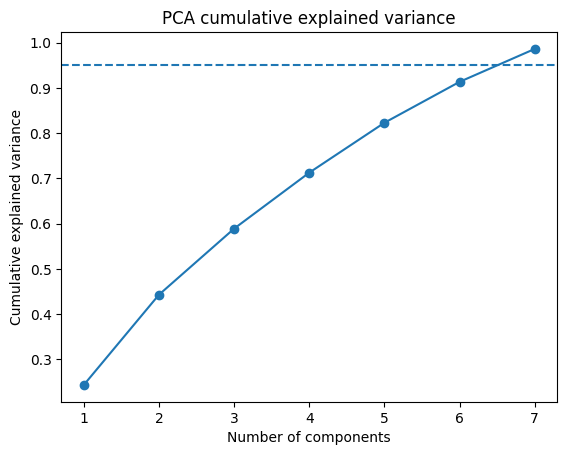

In [ ]:

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Original feature dim:", X_train_scaled.shape[1])
print("PCA components chosen:", pca.n_components_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure()
plt.plot(np.arange(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.show()


### B) Visualization (PC1 vs PC2)

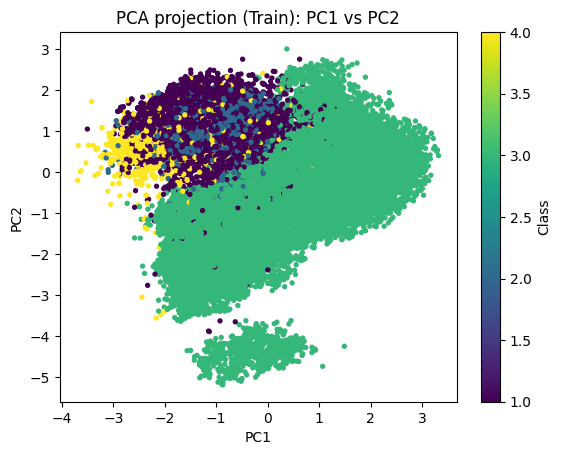

In [ ]:

plt.figure()
sc = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection (Train): PC1 vs PC2")
plt.colorbar(sc, label="Class")
plt.show()


### C) Kernel PCA (linear, RBF, polynomial)

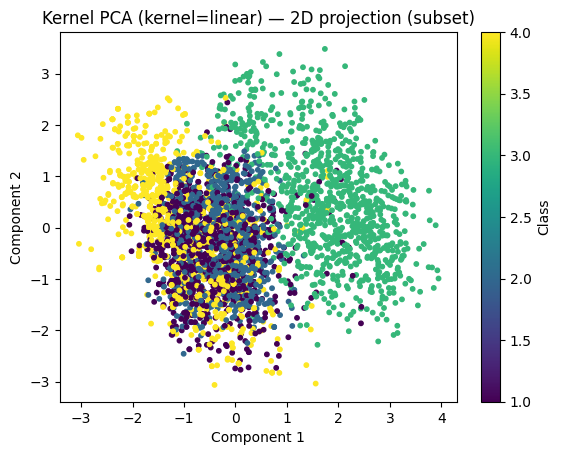

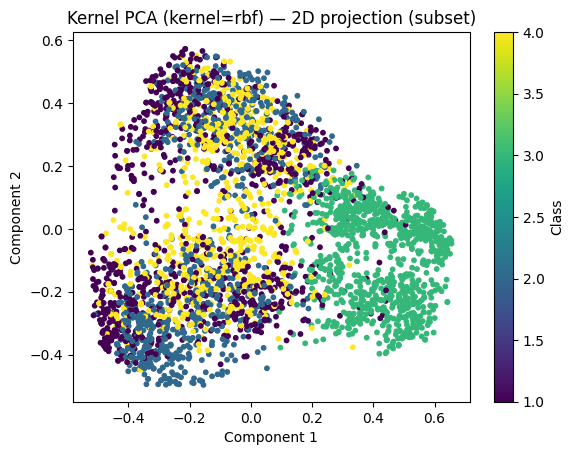

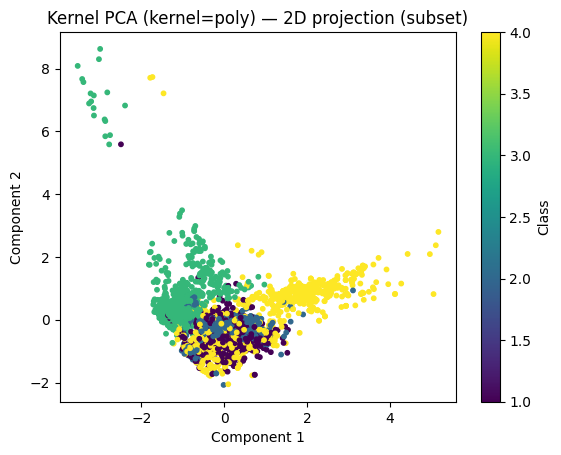

Comment: RBF/poly Kernel PCA can reveal non-linear structure that linear PCA may miss, but it is more expensive and does not always improve classification.


In [ ]:

KPCA_SUB = 4000
X_kpca_sub, y_kpca_sub = stratified_subsample(X_train_scaled, y_train, KPCA_SUB)

kernels = [
    ("linear", {}),
    ("rbf", {"gamma": "scale"}),
    ("poly", {"gamma": "scale", "degree": 3, "coef0": 1.0}),
]

for kname, params in kernels:
    if params.get("gamma") == "scale":
        gamma_val = 1.0 / (X_kpca_sub.shape[1] * np.var(X_kpca_sub) + 1e-12)
        params = {**params, "gamma": gamma_val}

    kpca = KernelPCA(n_components=2, kernel=kname, **params)
    Z = kpca.fit_transform(X_kpca_sub)

    plt.figure()
    sc = plt.scatter(Z[:, 0], Z[:, 1], c=y_kpca_sub, s=10)
    plt.title(f"Kernel PCA (kernel={kname}) — 2D projection (subset)")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.colorbar(sc, label="Class")
    plt.show()

print("Comment: RBF/poly Kernel PCA can reveal non-linear structure that linear PCA may miss, "
      "but it is more expensive and does not always improve classification.")


## Part 4: Classification on the PCA-Reduced Dataset

In [ ]:

results_pca = []

# Bayes scratch on PCA features
bayes_pca = GaussianBayesScratch(reg=1e-3)
bayes_pca.fit(X_train_pca, y_train)
y_pred_bayes_pca = bayes_pca.predict(X_test_pca)
results_pca.append(evaluate_classifier("Bayes (scratch) — PCA features", y_test, y_pred_bayes_pca, labels=labels_sorted))

# Linear SVM on PCA
lin_svm_pca = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000)
lin_svm_pca.fit(X_train_pca, y_train)
y_pred_lin_svm_pca = lin_svm_pca.predict(X_test_pca)
results_pca.append(evaluate_classifier("Linear SVM — PCA features", y_test, y_pred_lin_svm_pca, labels=labels_sorted))

# Kernel SVM on PCA (subset)
X_train_pca_sub, y_train_pca_sub = stratified_subsample(X_train_pca, y_train, SVM_TRAIN_SUB)
X_test_pca_sub,  y_test_pca_sub  = stratified_subsample(X_test_pca,  y_test,  SVM_TEST_SUB)

rbf_svm_pca = SVC(kernel="rbf", C=5.0, gamma="scale", random_state=RANDOM_STATE)
rbf_svm_pca.fit(X_train_pca_sub, y_train_pca_sub)
y_pred_rbf_svm_pca = rbf_svm_pca.predict(X_test_pca_sub)
results_pca.append(evaluate_classifier("RBF SVM — PCA features (subset)", y_test_pca_sub, y_pred_rbf_svm_pca, labels=labels_sorted))

poly_svm_pca = SVC(kernel="poly", C=2.0, degree=3, gamma="scale", coef0=1.0, random_state=RANDOM_STATE)
poly_svm_pca.fit(X_train_pca_sub, y_train_pca_sub)
y_pred_poly_svm_pca = poly_svm_pca.predict(X_test_pca_sub)
results_pca.append(evaluate_classifier("Poly SVM — PCA features (subset)", y_test_pca_sub, y_pred_poly_svm_pca, labels=labels_sorted))

# KNN on PCA
# For speed, use a stratified subset for KNN on PCA
X_train_fast_pca, y_train_fast_pca = stratified_subsample(X_train_pca, y_train, FAST_TRAIN_SUB)
X_test_fast_pca,  y_test_fast_pca  = stratified_subsample(X_test_pca,  y_test,  FAST_TEST_SUB)
print('FAST PCA subset:', X_train_fast_pca.shape, X_test_fast_pca.shape)
knn_ks = [3, 5, 11]
knn_scores_pca = []
for k in knn_ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_fast_pca, y_train_fast_pca)
    y_pred_knn_pca = knn.predict(X_test_fast_pca)
    knn_scores_pca.append((k, accuracy_score(y_test_fast_pca, y_pred_knn_pca), f1_score(y_test_fast_pca, y_pred_knn_pca, average="macro")))
    results_pca.append(evaluate_classifier(f"KNN (k={k}) — PCA features (subset)", y_test_fast_pca, y_pred_knn_pca, labels=labels_sorted, show_cm=False))

display(pd.DataFrame(knn_scores_pca, columns=["k", "Accuracy", "F1_macro"]).sort_values("Accuracy", ascending=False))
best_k_pca = sorted(knn_scores_pca, key=lambda t: t[1], reverse=True)[0][0]
print("Best k (PCA) by Accuracy:", best_k_pca)

# GaussianNB on PCA
gnb_pca = GaussianNB()
gnb_pca.fit(X_train_pca, y_train)
y_pred_gnb_pca = gnb_pca.predict(X_test_pca)
results_pca.append(evaluate_classifier("GaussianNB — PCA features", y_test, y_pred_gnb_pca, labels=labels_sorted))

# LDA on PCA
lda_pca = LinearDiscriminantAnalysis()
lda_pca.fit(X_train_pca, y_train)
y_pred_lda_pca = lda_pca.predict(X_test_pca)
results_pca.append(evaluate_classifier("LDA — PCA features", y_test, y_pred_lda_pca, labels=labels_sorted))

# KDA on PCA (subset)
X_train_kda_pca, y_train_kda_pca = stratified_subsample(X_train_pca, y_train, KDA_TRAIN_SUB)
X_test_kda_pca,  y_test_kda_pca  = stratified_subsample(X_test_pca,  y_test,  KDA_TEST_SUB)

kda_rbf_pca = KDAFromScratch(kernel="rbf", gamma="scale", reg=1e-3)
kda_rbf_pca.fit(X_train_kda_pca, y_train_kda_pca)
y_pred_kda_rbf_pca = kda_rbf_pca.predict(X_test_kda_pca)
results_pca.append(evaluate_classifier("KDA (RBF) — PCA features (subset)", y_test_kda_pca, y_pred_kda_rbf_pca, labels=labels_sorted))

kda_poly_pca = KDAFromScratch(kernel="poly", gamma="scale", degree=3, coef0=1.0, reg=1e-3)
kda_poly_pca.fit(X_train_kda_pca, y_train_kda_pca)
y_pred_kda_poly_pca = kda_poly_pca.predict(X_test_kda_pca)
results_pca.append(evaluate_classifier("KDA (Poly) — PCA features (subset)", y_test_kda_pca, y_pred_kda_poly_pca, labels=labels_sorted))

# Random Forest on PCA
rf_pca = RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1)
X_train_rf_pca, y_train_rf_pca = stratified_subsample(X_train_pca, y_train, FAST_TRAIN_SUB)
X_test_rf_pca, y_test_rf_pca = stratified_subsample(X_test_pca, y_test, FAST_TEST_SUB)
rf_pca.fit(X_train_rf_pca, y_train_rf_pca)
y_pred_rf_pca = rf_pca.predict(X_test_rf_pca)
results_pca.append(evaluate_classifier("Random Forest — PCA features (subset)", y_test_rf_pca, y_pred_rf_pca, labels=labels_sorted))



===== Bayes (scratch) — PCA features =====
Accuracy: 0.9468920537734593
F1 (macro): 0.8224377750677455

Classification report:
              precision    recall  f1-score   support

           1     0.8595    0.9302    0.8935      3282
           2     0.8642    0.7709    0.8149       982
           3     0.9893    0.9895    0.9894     10304
           4     0.7603    0.4847    0.5920       458

    accuracy                         0.9469     15026
   macro avg     0.8683    0.7938    0.8224     15026
weighted avg     0.9458    0.9469    0.9449     15026


===== Linear SVM — PCA features =====
Accuracy: 0.8952482363902569
F1 (macro): 0.5084293565251731

Classification report:
              precision    recall  f1-score   support

           1     0.6939    0.9595    0.8054      3282
           2     0.7500    0.0061    0.0121       982
           3     0.9824    0.9936    0.9880     10304
           4     1.0000    0.1288    0.2282       458

    accuracy                         0.895

,k,Accuracy,F1_macro
0,3,0.940609,0.920555
1,5,0.936041,0.915511
2,11,0.912944,0.876127


Best k (PCA) by Accuracy: 3

===== GaussianNB — PCA features =====
Accuracy: 0.8976440835884467
F1 (macro): 0.607566397087399

Classification report:
              precision    recall  f1-score   support

           1     0.7324    0.8964    0.8061      3282
           2     0.6929    0.0896    0.1587       982
           3     0.9629    0.9999    0.9811     10304
           4     0.8516    0.3384    0.4844       458

    accuracy                         0.8976     15026
   macro avg     0.8100    0.5811    0.6076     15026
weighted avg     0.8915    0.8976    0.8740     15026


===== LDA — PCA features =====
Accuracy: 0.8902568880606948
F1 (macro): 0.5550961208421833

Classification report:
              precision    recall  f1-score   support

           1     0.7021    0.9595    0.8109      3282
           2     0.3121    0.0896    0.1392       982
           3     0.9883    0.9766    0.9824     10304
           4     1.0000    0.1681    0.2879       458

    accuracy               

## Part 5: Performance Comparison and Discussion
### A) Summary Table

In [ ]:

def best_knn(results_list):
    candidates = [r for r in results_list if r["Classifier"].startswith("KNN (k=")]
    if not candidates:
        return (np.nan, np.nan, "KNN (best)")
    best = sorted(candidates, key=lambda r: r["Accuracy"], reverse=True)[0]
    return (best["Accuracy"], best["F1_macro"], best["Classifier"])

def metric_for(results_list, contains):
    for r in results_list:
        if contains in r["Classifier"]:
            return (r["Accuracy"], r["F1_macro"])
    return (np.nan, np.nan)

knn_acc_no, knn_f1_no, knn_name_no = best_knn(results_no_pca)
knn_acc_pca, knn_f1_pca, knn_name_pca = best_knn(results_pca)

summary_rows = [
    ("Bayes (scratch)",          *metric_for(results_no_pca, "Bayes (scratch)"),          *metric_for(results_pca, "Bayes (scratch)")),
    ("GaussianNB",               *metric_for(results_no_pca, "GaussianNB"),               *metric_for(results_pca, "GaussianNB")),
    (f"KNN (best) — {knn_name_no}", knn_acc_no, knn_f1_no, knn_acc_pca, knn_f1_pca),
    ("Linear SVM",               *metric_for(results_no_pca, "Linear SVM"),               *metric_for(results_pca, "Linear SVM")),
    ("RBF SVM",                  *metric_for(results_no_pca, "RBF SVM"),                  *metric_for(results_pca, "RBF SVM")),
    ("Poly SVM",                 *metric_for(results_no_pca, "Poly SVM"),                 *metric_for(results_pca, "Poly SVM")),
    ("LDA",                      *metric_for(results_no_pca, "LDA"),                      *metric_for(results_pca, "LDA")),
    ("KDA (RBF)",                *metric_for(results_no_pca, "KDA (RBF)"),                *metric_for(results_pca, "KDA (RBF)")),
    ("KDA (Poly)",               *metric_for(results_no_pca, "KDA (Poly)"),               *metric_for(results_pca, "KDA (Poly)")),
    ("Random Forest",            *metric_for(results_no_pca, "Random Forest"),            *metric_for(results_pca, "Random Forest")),
]

summary = pd.DataFrame(summary_rows, columns=["Classifier", "Accuracy (No PCA)", "F1 (No PCA)", "Accuracy (PCA)", "F1 (PCA)"])
display(summary)

print("\nNote: Kernel SVM and KDA are evaluated on stratified subsets due to O(n^2) scaling.")


,Classifier,Accuracy (No PCA),F1 (No PCA),Accuracy (PCA),F1 (PCA)
0,Bayes (scratch),0.955211,0.830861,0.946892,0.822438
1,GaussianNB,0.940503,0.792499,0.897644,0.607566
2,KNN (best) — KNN (k=3) — full features (subset),0.944416,0.925414,0.940609,0.920555
3,Linear SVM,0.910023,0.587946,0.895248,0.508429
4,RBF SVM,0.925381,0.893215,0.914213,0.879791
5,Poly SVM,0.920812,0.886323,0.909137,0.872414
6,LDA,0.907627,0.576772,0.890257,0.555096
7,KDA (RBF),0.876404,0.871565,0.860572,0.854495
8,KDA (Poly),0.859040,0.852691,0.807457,0.800490
9,Random Forest,0.969543,0.958368,0.949492,0.932453



Note: Kernel SVM and KDA are evaluated on stratified subsets due to O(n^2) scaling.



1) **Which classifier performed best without PCA?**  
- Best without PCA: Random Forest performed best because it doesn't rely of distance calculations and deals with high dimension data well without requiring dimension reduction.

2) **Which classifier performed best with PCA?**  
- Best with PCA: **Random Forest**

3) **Did PCA improve results for SVM / KNN / LDA?**  
- Yes PCA often helps SVN performance since it takes away noise and redundant features. PCA can improve KNN since distance calculations are more important after unimportant dimensions are removed Though, if PCA takes away useful info, performance might increase a little. PCA might help LDA. LDA does dimensionality reduction internally so using PCA beforehand may remove useful class separating info.

   **Did PCA improve results for Random Forest?**  
- PCA didn't really improve Random Forest performance because it works well with original feature space and it does feature selection internally. PCA supports models like SVN and KNN because they rely on distance calculations and linear separability.

4) **Comparing Bayes-from-scratch classifier vs GaussianNB.**   
- GaussianNB assumes features are independent, uses diagonal covariance matrix, and is faster. Bayes-from-scratch uses correlations between features, utilizes the full covariance matrix and is more flexible, but may overfit.

   **Comparing KDA vs SVM kernels.**    
- SVM highlights support vectors and maximizes the margin between classes. KDA maximizes between class separation and within class variance, uses global class structure and is more sensitive to sample size.

5) **Effect of different kernels (RBF vs Polynomial) in SVM and KDA.**  
- RBF: flexible and captures complex nonlinear patterns; sensitive to gamma/C.  
- Poly: global polynomial structure; sensitive to degree/coef0.  
- Observations: RBF usually performed better since it adapts to local structure while polynomial kernels were not as consistent and more sensitive to certain parameters.
